# Interactive Fantasy Draft with Trained Value MLP

This notebook loads the trained `value_mlp.pt` checkpoint (trained on Google Colab or locally) and allows you to:
1. **Inspect checkpoint metadata**: model architecture, training/test metrics, and feature normalizers.
2. **Evaluate Round 1 choices**: see exactly how the neural network ranks every legal player action for any draft position (e.g. pick 1.01 vs 1.05 vs 1.10) and league format (1-QB vs 2-QB, 1 vs 2 FLEX).
3. **Simulate an entire draft**: our controlled team uses the neural network ($\arg\max_a \hat{V}(T(s, a))$) while opponent teams draft realistically with `RosterAwareSoftmaxPolicy`.
4. **Evaluate season outcomes**: simulate full 14-week seasons with injuries and waiver replacements to see how the drafted team performs against the league.
5. **Multi-Draft Statistical Benchmark**: empirically test if and by how much the MLP consistently outperforms `RosterAwareSoftmaxPolicy` across multiple draft positions.

## 1. Imports and Device Setup


In [7]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

# Ensure fantasy_draft package is discoverable
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fantasy_draft.config import LeagueConfig, RosterConfig
from fantasy_draft.draft import DraftEnvironment, DraftState
from fantasy_draft.models import POSITIONS, Position
from fantasy_draft.players import generate_players
from fantasy_draft.policies import RosterAwareSoftmaxPolicy
from fantasy_draft.season import SeasonSimulator, mean_weekly_score
from fantasy_draft.state import StateEncoder
from fantasy_draft.waivers import PoolReplacementLevelModel

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


Using device: mps


## 2. Load the Checkpoint and Model

Loads `value_mlp.pt` from `models/value_mlp.pt` (or `data/`, current dir, or Colab `/content`).

In [8]:
class ValueMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: tuple[int, ...] = (256, 128, 64),
        dropout: float = 0.10,
    ) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        previous = input_dim
        for width in hidden_dims:
            layers.extend(
                [
                    nn.Linear(previous, width),
                    nn.LayerNorm(width),
                    nn.GELU(),
                    nn.Dropout(dropout),
                ]
            )
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# Search candidate paths for value_mlp.pt
candidate_paths = [
    ROOT / "models" / "value_mlp.pt",
    ROOT / "data" / "value_mlp.pt",
    Path("value_mlp.pt"),
    Path("models/value_mlp.pt"),
    Path("data/value_mlp.pt"),
    Path("/content/value_mlp.pt"),
]

checkpoint_path = next((p for p in candidate_paths if p.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError(
        f"Could not find 'value_mlp.pt'. Checked: {[str(p) for p in candidate_paths]}\n"
        "Please place your value_mlp.pt file in the models/ or data/ folder."
    )

print(f"Loading checkpoint from: {checkpoint_path.resolve()}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

model_config = checkpoint["model_config"]
model = ValueMLP(**model_config).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

feature_mean = checkpoint["feature_mean"].to(DEVICE).float()
feature_std = checkpoint["feature_std"].to(DEVICE).float()
target_mean = float(checkpoint["target_mean"])
target_std = float(checkpoint["target_std"])

print("\n--- Model Loaded Successfully ---")
print(f"Architecture: {model_config['input_dim']} -> {' -> '.join(map(str, model_config['hidden_dims']))} -> 1")
print(f"Target Normalization: mean={target_mean:.3f}, std={target_std:.3f}")
if "test_metrics" in checkpoint:
    print(f"Test Set Performance: {checkpoint['test_metrics']}")


Loading checkpoint from: /Users/zubinoommen/Documents/senior year/fall/projects/fantasy drafter rl/models/value_mlp.pt

--- Model Loaded Successfully ---
Architecture: 390 -> 256 -> 128 -> 64 -> 1
Target Normalization: mean=115.800, std=12.699
Test Set Performance: {'MAE': 2.429272413253784, 'RMSE': 3.0666788356650136, 'R2': 0.9423301815986633}


## 3. Define the Value-Network Drafting Agent

For any given `state`:
1. Enumerate all legal player IDs $a$.
2. Step to the exact post-pick state $s' = T(s, a)$.
3. Encode each post-pick state into the 390-D canonical feature vector.
4. Normalize and pass through `model` in a single batch.
5. Rank all candidate picks by predicted weekly points $\hat{V}(s')$, choosing $\arg\max_a \hat{V}(T(s, a))$.

In [9]:
class MLPDraftAgent:
    def __init__(self, model: nn.Module, feature_mean: torch.Tensor, feature_std: torch.Tensor, target_mean: float, target_std: float, device: torch.device) -> None:
        self.model = model
        self.feature_mean = feature_mean
        self.feature_std = feature_std
        self.target_mean = target_mean
        self.target_std = target_std
        self.device = device
        self.encoder = StateEncoder()

    def rank_candidates(self, state: DraftState, environment: DraftEnvironment) -> pd.DataFrame:
        """Rank all legal picks from best to worst by predicted weekly team points."""
        legal_actions = environment.legal_actions(state)
        if not legal_actions:
            raise ValueError("No legal actions available.")

        next_states = [environment.step(state, action, validate=False) for action in legal_actions]
        vectors = np.stack([self.encoder.encode_state(s_prime) for s_prime in next_states])

        tensor_x = torch.from_numpy(vectors).to(self.device).float()
        norm_x = (tensor_x - self.feature_mean) / self.feature_std

        self.model.eval()
        with torch.no_grad():
            norm_preds = self.model(norm_x).cpu().numpy().ravel()

        predicted_rewards = norm_preds * self.target_std + self.target_mean

        player_map = state.player_map
        rows = []
        for action, pred_val in zip(legal_actions, predicted_rewards):
            p = player_map[action]
            rows.append({
                "player_id": p.player_id,
                "position": p.position.value,
                "mu": p.mu,
                "sigma": p.sigma,
                "injury_prob": p.injury_probability,
                "predicted_reward": pred_val,
            })
        df = pd.DataFrame(rows).sort_values("predicted_reward", ascending=False).reset_index(drop=True)
        df["margin_to_best"] = df["predicted_reward"] - df["predicted_reward"].iloc[0]
        return df

    def select_player(self, state: DraftState, environment: DraftEnvironment, rng: np.random.Generator | None = None) -> int:
        """Greedy argmax pick."""
        leaderboard = self.rank_candidates(state, environment)
        return int(leaderboard.iloc[0]["player_id"])


agent = MLPDraftAgent(model, feature_mean, feature_std, target_mean, target_std, DEVICE)
print("Draft agent initialized.")


Draft agent initialized.


## 4. Evaluate Round 1 Picks across Different Draft Slots

Inspect what the neural network recommends for **Pick 1.01** (or any slot). Shift `controlled_slot` or `qb_count` to inspect how strategy shifts between 1-QB and 2-QB leagues.

In [10]:
# Customize draft scenario:
TEAMS = 10
CONTROLLED_SLOT = 0  # 0 = 1.01, 4 = 1.05, 9 = 1.10
QB_STARTERS = 1       # Try 1 vs 2
FLEX_SLOTS = 1        # Try 1 vs 2
BENCH_SLOTS = 3
SEED = 42

league = LeagueConfig(
    n_teams=TEAMS,
    controlled_team=CONTROLLED_SLOT,
    roster=RosterConfig(
        required={Position.QB: QB_STARTERS, Position.RB: 2, Position.WR: 2, Position.TE: 1},
        flex_slots=FLEX_SLOTS,
        bench_slots=BENCH_SLOTS,
    ),
)
env = DraftEnvironment(league)
players = generate_players(seed=SEED)
state = env.initial_state(players)

print(f"League format: {TEAMS}-team | {QB_STARTERS}-QB | {FLEX_SLOTS}-FLEX")
print(f"Our draft slot: Team {CONTROLLED_SLOT} (Pick #{CONTROLLED_SLOT + 1})")

# If we are not pick 1.01, advance the draft up to our turn using the realistic opponent policy:
opp_policy = RosterAwareSoftmaxPolicy(temperature=3.0)
sim_rng = np.random.default_rng(SEED)
while state.current_team != CONTROLLED_SLOT:
    act = opp_policy.select_player(state, env, sim_rng)
    state = env.step(state, act, validate=False)

# Now evaluate all legal options at our turn:
round1_rankings = agent.rank_candidates(state, env)
top_pick = round1_rankings.iloc[0]

print("\n" + "=" * 65)
print(f"  RECOMMENDED PICK: {top_pick['position']} #{int(top_pick['player_id'])}")
print(f"  Projected Value:  {top_pick['predicted_reward']:.3f} weekly pts")
print(f"  Player Stats:     mu={top_pick['mu']:.2f}, sigma={top_pick['sigma']:.2f}, injury_p={top_pick['injury_prob']:.3f}")
print("=" * 65 + "\n")

print("Top 10 Overall Candidates:")
display(round1_rankings.head(10))

print("\nBest Candidate Per Position:")
pos_summary = round1_rankings.groupby("position", as_index=False).first().sort_values("predicted_reward", ascending=False)
display(pos_summary)


League format: 10-team | 1-QB | 1-FLEX
Our draft slot: Team 0 (Pick #1)

  RECOMMENDED PICK: RB #24
  Projected Value:  101.557 weekly pts
  Player Stats:     mu=21.75, sigma=6.85, injury_p=0.115

Top 10 Overall Candidates:


,player_id,position,mu,sigma,injury_prob,predicted_reward,margin_to_best
0,24,RB,21.7545,6.8476,0.11544,101.556549,0.000000
1,60,WR,21.4463,6.8843,0.05358,100.178596,-1.377953
2,0,QB,24.3347,5.3116,0.05136,100.170547,-1.386002
3,102,TE,16.4197,7.0901,0.12666,98.924889,-2.631660
4,1,QB,23.3338,6.5026,0.07851,98.662560,-2.893990
5,63,WR,18.2524,9.3286,0.01167,98.357224,-3.199326
6,62,WR,19.6857,7.0999,0.09734,98.152519,-3.404030
7,61,WR,19.8364,8.3106,0.09378,97.983498,-3.573051
8,2,QB,22.1277,6.9023,0.04377,97.957848,-3.598701
9,3,QB,22.0494,7.0530,0.04789,97.823036,-3.733513



Best Candidate Per Position:


,position,player_id,mu,sigma,injury_prob,predicted_reward,margin_to_best
1,RB,24,21.7545,6.8476,0.11544,101.556549,0.000000
3,WR,60,21.4463,6.8843,0.05358,100.178596,-1.377953
0,QB,0,24.3347,5.3116,0.05136,100.170547,-1.386002
2,TE,102,16.4197,7.0901,0.12666,98.924889,-2.631660


## 5. Simulate a Complete Draft with the Neural Network

Here our team uses `MLPDraftAgent` on every one of its picks, while all opponent teams draft with `RosterAwareSoftmaxPolicy`.
Watch the pick-by-pick log as our agent navigates positional runs, roster need constraints, and value.

In [11]:
# Fresh draft setup
state = env.initial_state(players)
draft_rng = np.random.default_rng(2026)
opp_policy = RosterAwareSoftmaxPolicy(temperature=3.0)

our_picks_log = []

print(f"Starting full snake draft ({league.n_rounds} rounds, {league.total_picks} total picks)...")
while not state.is_terminal:
    current_team = state.current_team
    pick_num = state.pick_index + 1
    round_num = state.round_number

    if current_team == league.controlled_team:
        # Neural network ranks and picks
        rankings = agent.rank_candidates(state, env)
        chosen_id = int(rankings.iloc[0]["player_id"])
        chosen_p = state.player_map[chosen_id]
        pred_val = rankings.iloc[0]["predicted_reward"]
        runner_up = rankings.iloc[1]

        our_picks_log.append({
            "Round": round_num,
            "Overall_Pick": pick_num,
            "Selected": f"{chosen_p.position.value} #{chosen_p.player_id}",
            "Position": chosen_p.position.value,
            "Player_Mu": chosen_p.mu,
            "Projected_Team_Value": round(pred_val, 2),
            "Next_Best_Alternative": f"{runner_up['position']} #{int(runner_up['player_id'])} ({runner_up['predicted_reward']:.2f})",
        })
        print(f"[Round {round_num:2d} | Pick {pick_num:3d}] WE DRAFT: {chosen_p.position.value} #{chosen_p.player_id:3d} (mu={chosen_p.mu:5.2f}) -> Proj Value: {pred_val:.2f} pts/wk")
        action = chosen_id
    else:
        action = opp_policy.select_player(state, env, draft_rng)

    state = env.step(state, action, validate=False)

print("\n--- Draft Completed! ---")
picks_df = pd.DataFrame(our_picks_log)
display(picks_df)


Starting full snake draft (10 rounds, 100 total picks)...
[Round  1 | Pick   1] WE DRAFT: RB # 24 (mu=21.75) -> Proj Value: 101.56 pts/wk
[Round  2 | Pick  20] WE DRAFT: QB #  2 (mu=22.13) -> Proj Value: 100.50 pts/wk
[Round  3 | Pick  21] WE DRAFT: RB # 27 (mu=15.24) -> Proj Value: 101.26 pts/wk
[Round  4 | Pick  40] WE DRAFT: TE #104 (mu=10.06) -> Proj Value: 102.39 pts/wk
[Round  5 | Pick  41] WE DRAFT: WR # 69 (mu=15.33) -> Proj Value: 105.24 pts/wk
[Round  6 | Pick  60] WE DRAFT: QB #  4 (mu=20.59) -> Proj Value: 104.73 pts/wk
[Round  7 | Pick  61] WE DRAFT: WR # 77 (mu=12.53) -> Proj Value: 106.26 pts/wk
[Round  8 | Pick  80] WE DRAFT: TE #113 (mu= 5.88) -> Proj Value: 105.53 pts/wk
[Round  9 | Pick  81] WE DRAFT: WR # 84 (mu=10.72) -> Proj Value: 106.04 pts/wk
[Round 10 | Pick 100] WE DRAFT: TE #115 (mu= 5.25) -> Proj Value: 111.98 pts/wk

--- Draft Completed! ---


,Round,Overall_Pick,Selected,Position,Player_Mu,Projected_Team_Value,Next_Best_Alternative
0,1,1,RB #24,RB,21.7545,101.559998,WR #60 (100.18)
1,2,20,QB #2,QB,22.1277,100.500000,QB #3 (100.39)
2,3,21,RB #27,RB,15.2363,101.260002,RB #30 (100.78)
3,4,40,TE #104,TE,10.0602,102.389999,TE #105 (102.33)
4,5,41,WR #69,WR,15.3297,105.239998,WR #72 (103.54)
5,6,60,QB #4,QB,20.5947,104.730003,WR #78 (104.63)
6,7,61,WR #77,WR,12.5317,106.260002,WR #74 (106.26)
7,8,80,TE #113,TE,5.8815,105.529999,TE #114 (105.30)
8,9,81,WR #84,WR,10.7163,106.040001,WR #83 (105.89)
9,10,100,TE #115,TE,5.2505,111.980003,TE #117 (111.96)


## 6. Inspect Final Rosters and Simulate a 14-Week Season

Let's see our drafted roster breakdown, and simulate 200 independent 14-week seasons with injuries and weekly waiver-wire pickups to see how our team scores against the opponents.

Our Final Roster Breakdown:


,Player ID,Position,Weekly Mu,Weekly Sigma,Injury Prob
0,2,QB,22.1277,6.9023,0.04377
1,4,QB,20.5947,5.5455,0.04809
2,24,RB,21.7545,6.8476,0.11544
3,27,RB,15.2363,8.3647,0.03061
4,69,WR,15.3297,9.4572,0.01229
5,77,WR,12.5317,7.1974,0.04265
6,84,WR,10.7163,8.7118,0.00496
7,104,TE,10.0602,5.6642,0.05922
8,113,TE,5.8815,4.5606,0.03063
9,115,TE,5.2505,6.8176,0.01433


,team,mean_weekly_points,std_weekly_points,min_season,max_season
0,OUR TEAM (MLP),105.512743,5.649360,92.730342,124.913126
1,Opponent 6,98.299604,5.147111,81.446187,110.913875
2,Opponent 3,97.429674,4.689526,85.266684,110.319798
3,Opponent 2,97.084395,4.384242,85.186024,106.765398
4,Opponent 1,96.976836,5.073560,85.099848,110.944122
5,Opponent 8,96.538471,3.902362,86.612384,107.150929
6,Opponent 9,92.822757,4.732871,80.818308,106.566668
7,Opponent 4,92.683207,5.288938,78.780530,106.269147
8,Opponent 7,88.506454,4.137448,79.877023,102.455824
9,Opponent 5,86.915359,4.674994,77.468323,97.460341


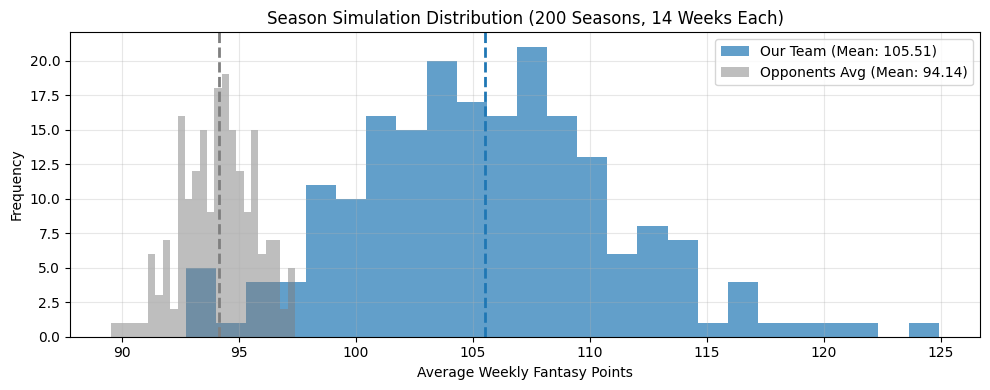

In [12]:
# Our final drafted roster
our_roster = state.roster_players(league.controlled_team)
our_roster_df = pd.DataFrame([
    {
        "Player ID": p.player_id,
        "Position": p.position.value,
        "Weekly Mu": p.mu,
        "Weekly Sigma": p.sigma,
        "Injury Prob": p.injury_probability,
    }
    for p in sorted(our_roster, key=lambda x: (POSITIONS.index(x.position), -x.mu))
])
print("Our Final Roster Breakdown:")
display(our_roster_df)

# Simulate 200 seasons for our team vs all opponent teams
simulator = SeasonSimulator(
    roster_config=league.roster,
    n_weeks=league.season_weeks,
    replacement_model=PoolReplacementLevelModel(),
)
free_agents = state.available_players()

N_SEASONS = 200
season_seeds = tuple(int(x) for x in draft_rng.integers(0, 1 << 31, size=N_SEASONS))

league_scores = []
for team_id in range(league.n_teams):
    roster = state.roster_players(team_id)
    seasons = simulator.simulate_many(roster, free_agents, season_seeds, player_universe=state.players)
    mean_scores = [mean_weekly_score(s.weekly_scores) for s in seasons]
    league_scores.append({
        "team": "OUR TEAM (MLP)" if team_id == league.controlled_team else f"Opponent {team_id}",
        "mean_weekly_points": np.mean(mean_scores),
        "std_weekly_points": np.std(mean_scores),
        "min_season": np.min(mean_scores),
        "max_season": np.max(mean_scores),
        "raw_scores": mean_scores,
    })

standings = pd.DataFrame(league_scores).sort_values("mean_weekly_points", ascending=False).reset_index(drop=True)
display(standings[["team", "mean_weekly_points", "std_weekly_points", "min_season", "max_season"]])

# Plot distribution of season outcomes
plt.figure(figsize=(10, 4))
our_scores = next(item["raw_scores"] for item in league_scores if item["team"] == "OUR TEAM (MLP)")
opp_avg_scores = np.mean([item["raw_scores"] for item in league_scores if item["team"] != "OUR TEAM (MLP)"], axis=0)

plt.hist(our_scores, bins=25, alpha=0.7, label=f"Our Team (Mean: {np.mean(our_scores):.2f})", color="tab:blue")
plt.hist(opp_avg_scores, bins=25, alpha=0.5, label=f"Opponents Avg (Mean: {np.mean(opp_avg_scores):.2f})", color="tab:gray")
plt.axvline(np.mean(our_scores), color="tab:blue", linestyle="--", linewidth=2)
plt.axvline(np.mean(opp_avg_scores), color="tab:gray", linestyle="--", linewidth=2)
plt.title(f"Season Simulation Distribution ({N_SEASONS} Seasons, 14 Weeks Each)")
plt.xlabel("Average Weekly Fantasy Points")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Multi-Draft Synthetic Benchmark

This benchmark compares the MLP and `RosterAwareSoftmaxPolicy` across multiple generated player pools and draft slots. It measures empirical performance; it is **not a policy-improvement guarantee**. The network only approximates $V^\pi$, and repeatedly deploying a greedy action changes the state distribution from the continuation policy used to generate its targets.

For each draft we report both the MLP team's advantage over the opponent field and a paired counterfactual where `RosterAwareSoftmaxPolicy` controls the same slot. Drafts share seeds where possible, but their boards diverge after different picks.

In [ ]:
BENCHMARK_DRAFTS = 10
SEASONS_PER_DRAFT = 100
TEST_SLOTS = [0, 4, 9]  # Pick 1.01, 1.05, 1.10

benchmark_records = []
print(f"Running multi-draft benchmark across {len(TEST_SLOTS)} draft slots ({BENCHMARK_DRAFTS} drafts each)...\n")

for slot in TEST_SLOTS:
    for d in range(BENCHMARK_DRAFTS):
        seed = 5000 + d * 17 + slot
        league_cfg = LeagueConfig(
            n_teams=10,
            controlled_team=slot,
            roster=RosterConfig(
                required={Position.QB: 1, Position.RB: 2, Position.WR: 2, Position.TE: 1},
                flex_slots=1,
                bench_slots=3,
            ),
        )
        env_cfg = DraftEnvironment(league_cfg)
        draft_players = generate_players(seed=seed)
        opp_pol = RosterAwareSoftmaxPolicy(temperature=3.0)
        sim = SeasonSimulator(roster_config=league_cfg.roster, n_weeks=league_cfg.season_weeks)
        eval_seeds = tuple(int(x) for x in np.random.default_rng(99).integers(0, 1 << 31, size=SEASONS_PER_DRAFT))

        # 1. Draft with MLP
        st1 = env_cfg.initial_state(draft_players)
        rng1 = np.random.default_rng(seed)
        while not st1.is_terminal:
            if st1.current_team == slot:
                act = agent.select_player(st1, env_cfg)
            else:
                act = opp_pol.select_player(st1, env_cfg, rng1)
            st1 = env_cfg.step(st1, act, validate=False)

        mlp_roster = st1.roster_players(slot)
        fa1 = st1.available_players()
        mlp_seasons = sim.simulate_many(mlp_roster, fa1, eval_seeds, player_universe=st1.players)
        mlp_score = float(np.mean([mean_weekly_score(s.weekly_scores) for s in mlp_seasons]))

        opp_scores = []
        for t in range(10):
            if t != slot:
                opp_res = sim.simulate_many(st1.roster_players(t), fa1, eval_seeds, player_universe=st1.players)
                opp_scores.append(float(np.mean([mean_weekly_score(s.weekly_scores) for s in opp_res])))
        league_opp_avg = float(np.mean(opp_scores))

        # 2. Paired draft with RosterAwareSoftmax at the exact same slot
        st2 = env_cfg.initial_state(draft_players)
        rng2 = np.random.default_rng(seed)
        while not st2.is_terminal:
            act = opp_pol.select_player(st2, env_cfg, rng2)
            st2 = env_cfg.step(st2, act, validate=False)

        ra_roster = st2.roster_players(slot)
        fa2 = st2.available_players()
        ra_seasons = sim.simulate_many(ra_roster, fa2, eval_seeds, player_universe=st2.players)
        ra_score = float(np.mean([mean_weekly_score(s.weekly_scores) for s in ra_seasons]))

        benchmark_records.append({
            "draft_slot": f"Slot {slot} (Pick {slot+1})",
            "draft_id": d + 1,
            "mlp_weekly_points": mlp_score,
            "ra_weekly_points": ra_score,
            "league_opp_avg": league_opp_avg,
            "paired_diff": mlp_score - ra_score,
            "beat_field": mlp_score > league_opp_avg,
            "beat_paired": mlp_score > ra_score,
        })

bench_df = pd.DataFrame(benchmark_records)
summary = bench_df.groupby("draft_slot").agg(
    mlp_mean=("mlp_weekly_points", "mean"),
    ra_mean=("ra_weekly_points", "mean"),
    opp_mean=("league_opp_avg", "mean"),
    paired_advantage=("paired_diff", "mean"),
    beat_paired_pct=("beat_paired", lambda x: f"{x.mean() * 100:.1f}%"),
    beat_field_pct=("beat_field", lambda x: f"{x.mean() * 100:.1f}%"),
).reset_index()

print("--- Benchmark Summary across Draft Slots ---")
display(summary)

# Plot Paired Advantage Boxplot
plt.figure(figsize=(8, 4.5))
slots = bench_df["draft_slot"].unique()
box_data = [bench_df[bench_df["draft_slot"] == s]["paired_diff"].values for s in slots]
plt.boxplot(box_data, tick_labels=slots, patch_artist=True, boxprops=dict(facecolor="lightblue", alpha=0.7))
plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="Zero Advantage")
plt.ylabel("Weekly Points Advantage (MLP - RosterAware)")
plt.title("Paired Weekly Advantage of Value MLP vs RosterAwareSoftmax")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Running multi-draft benchmark across 3 draft slots (10 drafts each)...



## 8. NFLfastR 2018–2025 Calibration and Ex-Post Benchmark

The artifacts below come from official nflverse weekly player stats and weekly rosters. For every player-season, `mu` and `sigma` are calculated over active regular-season team-game weeks; active games with no box-score production count as zero, and bye weeks are excluded. `injury_probability` is the observed fraction of team-game weeks with a non-active roster status.

The comparison is a **hindsight distribution benchmark**: each simulated draft knows that season's ex-post player distributions. It is not a reconstruction of actual historical fantasy drafts because nflfastR does not contain fantasy ADP or draft-room histories. Both policies see the same historical season pool and use paired seeds.

In [ ]:
HISTORICAL_DIR = ROOT / "data" / "nflfastr"
PLAYER_SEASONS_PATH = HISTORICAL_DIR / "player_seasons.parquet"
CALIBRATION_PATH = HISTORICAL_DIR / "calibration.json"
BENCHMARK_PATH = HISTORICAL_DIR / "hindsight_benchmark.parquet"

required_artifacts = [PLAYER_SEASONS_PATH, CALIBRATION_PATH, BENCHMARK_PATH]
missing = [path for path in required_artifacts if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing historical artifacts. Run `python scripts/calibrate_nflfastr.py` first. "
        f"Missing: {missing}"
    )

import json

historical_players = pd.read_parquet(PLAYER_SEASONS_PATH)
hindsight = pd.read_parquet(BENCHMARK_PATH)
with open(CALIBRATION_PATH, encoding="utf-8") as handle:
    calibration = json.load(handle)

print(
    f"Loaded {len(historical_players):,} player-seasons from "
    f"{min(calibration['seasons'])}–{max(calibration['seasons'])}."
)

historical_summary = (
    historical_players.groupby("position")
    .agg(
        player_seasons=("player_id", "size"),
        mean_weekly_mu=("mu", "mean"),
        median_weekly_mu=("mu", "median"),
        mean_weekly_sigma=("sigma", "mean"),
        mean_unavailable_probability=("injury_probability", "mean"),
    )
    .reindex(["QB", "RB", "WR", "TE"])
    .reset_index()
)
display(historical_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for position, group in historical_players.groupby("position"):
    axes[0].hist(group["mu"], bins=25, alpha=0.45, label=position)
    axes[1].hist(group["sigma"], bins=25, alpha=0.45, label=position)
    axes[2].hist(group["injury_probability"], bins=20, alpha=0.45, label=position)
axes[0].set_title("Active-week mean")
axes[1].set_title("Active-week standard deviation")
axes[2].set_title("Observed unavailability")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
season_summary = (
    hindsight.groupby("season")
    .agg(
        trials=("paired_advantage", "size"),
        mlp_weekly_points=("mlp_weekly_points", "mean"),
        roster_aware_weekly_points=("baseline_weekly_points", "mean"),
        opponent_field_weekly_points=("opponent_field_weekly_points", "mean"),
        paired_advantage=("paired_advantage", "mean"),
        field_advantage=("field_advantage", "mean"),
        paired_win_rate=("paired_advantage", lambda values: (values > 0).mean()),
    )
    .reset_index()
)
print("Ex-post historical-distribution results by NFL season:")
display(season_summary)

overall_advantage = hindsight["paired_advantage"].mean()
overall_se = hindsight["paired_advantage"].std(ddof=1) / np.sqrt(len(hindsight))
overall_win_rate = (hindsight["paired_advantage"] > 0).mean()
print(
    f"Overall paired MLP advantage: {overall_advantage:+.2f} points/week "
    f"(approx. 95% CI {overall_advantage - 1.96 * overall_se:+.2f} to "
    f"{overall_advantage + 1.96 * overall_se:+.2f}); "
    f"paired trial win rate: {overall_win_rate:.1%}."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].bar(season_summary["season"].astype(str), season_summary["paired_advantage"])
axes[0].set_title("MLP advantage over same-slot RosterAware")
axes[0].set_ylabel("Expected points/week")
axes[0].tick_params(axis="x", rotation=45)

slot_data = [
    group["paired_advantage"].to_numpy()
    for _, group in hindsight.groupby("draft_slot", sort=True)
]
slot_labels = [f"Pick {slot + 1}" for slot in sorted(hindsight["draft_slot"].unique())]
axes[1].boxplot(slot_data, tick_labels=slot_labels)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Paired advantage by draft slot")
axes[1].set_ylabel("Expected points/week")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Reconstruct a 2025 All-MLP Hindsight Draft Board

This draft uses the top 2025 QB/RB/WR/TE player-season distributions known **ex post**. Every fantasy team uses the same trained MLP greedily. Before each pick, the state is viewed from the drafting team's perspective so the encoder uses that team's roster, slot, and upcoming picks.

This is a model diagnostic—not a claim about what managers should have known before the 2025 season. The player pool uses realized active-week mean, volatility, and roster unavailability, and no historical ADP constraints are imposed.

In [ ]:
from dataclasses import replace

from fantasy_draft.historical import HISTORICAL_POOL_COUNTS, historical_player_pool

HINDSIGHT_SEASON = 2025
ALL_MLP_TEAMS = 10

# Recreate the ID-to-name mapping in the same deterministic order used by
# historical_player_pool.
season_2025 = historical_players[historical_players["season"].eq(HINDSIGHT_SEASON)]
player_name_by_id = {}
next_player_id = 0
for position in POSITIONS:
    selected = (
        season_2025[season_2025["position"].eq(position.value)]
        .sort_values(["mu", "player_id"], ascending=[False, True])
        .head(HISTORICAL_POOL_COUNTS[position])
    )
    for row in selected.itertuples(index=False):
        player_name_by_id[next_player_id] = row.player_name
        next_player_id += 1

players_2025 = historical_player_pool(historical_players, HINDSIGHT_SEASON)
all_mlp_league = LeagueConfig(
    n_teams=ALL_MLP_TEAMS,
    controlled_team=0,
    roster=RosterConfig(
        required={Position.QB: 1, Position.RB: 2, Position.WR: 2, Position.TE: 1},
        flex_slots=1,
        bench_slots=3,
    ),
)
all_mlp_env = DraftEnvironment(all_mlp_league)
all_mlp_state = all_mlp_env.initial_state(players_2025)
all_mlp_picks = []

while not all_mlp_state.is_terminal:
    drafting_team = all_mlp_state.current_team
    assert drafting_team is not None

    # StateEncoder encodes config.controlled_team. Create a read-only perspective
    # for the team currently on the clock, then apply its choice to the real state.
    team_config = replace(all_mlp_league, controlled_team=drafting_team)
    team_state = replace(all_mlp_state, config=team_config)
    team_env = DraftEnvironment(team_config)
    rankings = agent.rank_candidates(team_state, team_env)
    choice = rankings.iloc[0]
    player_id = int(choice["player_id"])
    player = all_mlp_state.player_map[player_id]

    all_mlp_picks.append(
        {
            "Round": all_mlp_state.round_number,
            "Overall": all_mlp_state.pick_index + 1,
            "Team": drafting_team + 1,
            "Player": player_name_by_id[player_id],
            "Position": player.position.value,
            "2025 Active-Week Mean": player.mu,
            "2025 Weekly Std": player.sigma,
            "2025 Unavailable Prob": player.injury_probability,
            "MLP Post-Pick Value": float(choice["predicted_reward"]),
        }
    )
    all_mlp_state = all_mlp_env.step(all_mlp_state, player_id, validate=False)

all_mlp_picks_df = pd.DataFrame(all_mlp_picks)
all_mlp_picks_df["Board Label"] = (
    all_mlp_picks_df["Player"] + " (" + all_mlp_picks_df["Position"] + ")"
)

# Conventional board orientation: columns are fixed draft slots; odd rounds run
# left-to-right and even rounds are naturally reversed by the snake order.
draft_board_2025 = all_mlp_picks_df.pivot(
    index="Round", columns="Team", values="Board Label"
).rename(columns=lambda team: f"Team {team}")

print("2025 ex-post all-MLP snake draft board:")
display(draft_board_2025)

print("\nDetailed pick log:")
display(
    all_mlp_picks_df.drop(columns="Board Label").style.format(
        {
            "2025 Active-Week Mean": "{:.2f}",
            "2025 Weekly Std": "{:.2f}",
            "2025 Unavailable Prob": "{:.1%}",
            "MLP Post-Pick Value": "{:.2f}",
        }
    )
)

print("\nFinal roster position counts by team:")
roster_counts_2025 = pd.DataFrame(
    [
        {
            "Team": team + 1,
            **{
                position.value: all_mlp_state.roster_position_counts(team)[position]
                for position in POSITIONS
            },
        }
        for team in range(ALL_MLP_TEAMS)
    ]
).set_index("Team")
display(roster_counts_2025)